<a href="https://colab.research.google.com/github/tanishqsayil-lab/MLEL--Experiment/blob/main/EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [43]:
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [44]:

df = df.replace("?", np.nan)
df = df.dropna()

In [47]:

df = pd.get_dummies(df)

In [48]:

y = df['class_>50K']

X = df.drop(['class_>50K', 'class_<=50K'], axis=1)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [50]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [51]:
y_pred = model.predict(X_test)

In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8101275152944645
Precision: 0.6232917409387998
Recall: 0.6159718144450969
F1 Score: 0.6196101594802126


AUC: 0.7459192236929071


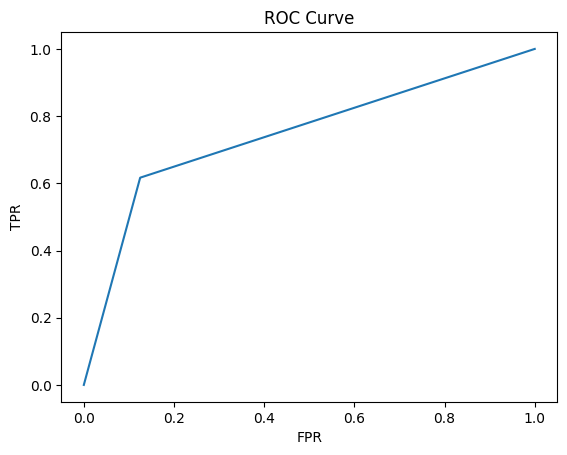

In [53]:
y_prob = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, y_prob))

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [54]:
scores = cross_val_score(model, X, y, cv=5)

print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Mean Accuracy: 0.8147142072330371
Std Dev: 0.0032974259353737035
